In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
import shap

In [5]:
print('All imports OK')

All imports OK


In [6]:
demo  = pd.read_sas('P_DEMO.XPT',  format='xport', encoding='utf-8')
bmx   = pd.read_sas('P_BMX.XPT',   format='xport', encoding='utf-8')
bpxo  = pd.read_sas('P_BPXO.xpt',  format='xport', encoding='utf-8')
tchol = pd.read_sas('P_TCHOL.xpt', format='xport', encoding='utf-8')
diq   = pd.read_sas('P_DIQ.xpt',   format='xport', encoding='utf-8')
cdq   = pd.read_sas('P_CDQ.xpt',   format='xport', encoding='utf-8')

In [7]:
# Merge — CDQ as base (adults 40+ only by design of CDQ questionnaire)
df = (cdq[['SEQN','CDQ001','CDQ010']]
      .merge(demo[['SEQN','RIDAGEYR','RIAGENDR','RIDRETH3','INDFMPIR',
                   'WTMECPRP','SDMVPSU','SDMVSTRA']], on='SEQN', how='left')
      .merge(bmx[['SEQN','BMXBMI','BMXWAIST']], on='SEQN', how='left')
      .merge(bpxo[['SEQN','BPXOSY1','BPXODI1']], on='SEQN', how='left')
      .merge(tchol[['SEQN','LBXTC']], on='SEQN', how='left')
      .merge(diq[['SEQN','DIQ010']], on='SEQN', how='left')
     )

print(f'Raw merged shape: {df.shape}')

Raw merged shape: (6433, 16)


In [8]:
# Drop don't know / refused responses on target
df = df[df['CDQ001'] != 9.0].copy()

# Binary target
df['cvd_symptom'] = (df['CDQ001'] == 1.0).astype(int)

# Shortness of breath (CDQ010) — correlated CVD symptom
df['sob'] = (df['CDQ010'] == 1.0).astype(int)

# Demographics
df['male'] = (df['RIAGENDR'] == 1.0).astype(int)
df['diabetes'] = (df['DIQ010'] == 1.0).astype(int)

# Race/ethnicity — keep raw for stratification, also dummy-encode for modeling
race_map = {1.0:'Hispanic', 2.0:'Hispanic', 3.0:'NH_White',
            4.0:'NH_Black', 6.0:'NH_Asian', 7.0:'Other'}
df['race_eth'] = df['RIDRETH3'].map(race_map)

# Rename continuous vars
df.rename(columns={
    'RIDAGEYR':'age', 'BMXBMI':'bmi', 'BMXWAIST':'waist_cm',
    'BPXOSY1':'sbp', 'BPXODI1':'dbp', 'LBXTC':'total_chol',
    'INDFMPIR':'income_pir'
}, inplace=True)

# Median imputation
for col in ['bmi','waist_cm','sbp','dbp','total_chol','income_pir']:
    df[col] = df[col].fillna(df[col].median())

# Clinical flag features
df['hypertension']   = (df['sbp'] >= 130).astype(int)
df['obese']          = (df['bmi'] >= 30).astype(int)
df['high_chol']      = (df['total_chol'] >= 200).astype(int)
df['pulse_pressure'] = df['sbp'] - df['dbp']

# Interaction terms
df['age_x_male']     = df['age'] * df['male']
df['age_x_diabetes'] = df['age'] * df['diabetes']
df['sbp_x_chol']     = df['sbp'] * df['total_chol']
df['bmi_x_diabetes'] = df['bmi'] * df['diabetes']

# Income bracket for stratification
df['income_bracket'] = pd.cut(df['income_pir'],
    bins=[0, 1.0, 2.0, 3.5, 5.1],
    labels=['<100% FPL', '100-200% FPL', '200-350% FPL', '>350% FPL'],
    include_lowest=True
)

print(f'Final shape: {df.shape}')
print(f'CVD positive rate: {df["cvd_symptom"].mean():.1%}')
print(f'\nRace/ethnicity distribution:')
print(df['race_eth'].value_counts())

Final shape: (6429, 30)
CVD positive rate: 29.5%

Race/ethnicity distribution:
race_eth
NH_White    2396
NH_Black    1723
Hispanic    1283
NH_Asian     750
Other        277
Name: count, dtype: int64


In [9]:
def weighted_prevalence(data, group_col, target='cvd_symptom', weight_col='WTMECPRP'):
    """Compute survey-weighted CVD prevalence by group."""
    results = []
    for group, grp in data.groupby(group_col, observed=True):
        w = grp[weight_col]
        y = grp[target]
        # Weighted proportion
        prev = (y * w).sum() / w.sum()
        n = len(grp)
        n_cases = y.sum()
        results.append({
            'Group': group,
            'N (unweighted)': n,
            'Cases': n_cases,
            'Weighted Prevalence (%)': round(prev * 100, 2)
        })
    return pd.DataFrame(results).sort_values('Weighted Prevalence (%)', ascending=False)

print('=== Survey-Weighted CVD Prevalence by Race/Ethnicity ===')
race_prev = weighted_prevalence(df, 'race_eth')
print(race_prev.to_string(index=False))

print('\n=== Survey-Weighted CVD Prevalence by Income Bracket ===')
income_prev = weighted_prevalence(df, 'income_bracket')
print(income_prev.to_string(index=False))

=== Survey-Weighted CVD Prevalence by Race/Ethnicity ===
   Group  N (unweighted)  Cases  Weighted Prevalence (%)
   Other             277    111                    42.46
NH_White            2396    794                    30.39
NH_Black            1723    510                    29.68
Hispanic            1283    369                    28.73
NH_Asian             750    112                    15.59

=== Survey-Weighted CVD Prevalence by Income Bracket ===
       Group  N (unweighted)  Cases  Weighted Prevalence (%)
   <100% FPL             960    358                    42.55
100-200% FPL            1456    466                    34.21
200-350% FPL            2146    624                    29.47
   >350% FPL            1867    448                    25.56


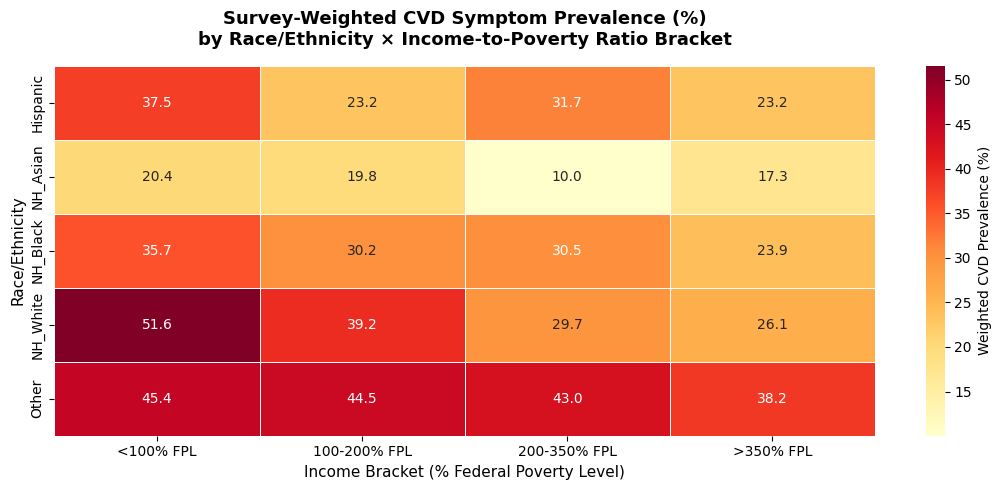

Saved: equity_heatmap.png


In [10]:
# ── Health Equity Summary: Race × Income ──────────────────────────────────────
equity_table = []
for race, rgrp in df.groupby('race_eth', observed=True):
    for income, igrp in rgrp.groupby('income_bracket', observed=True):
        w = igrp['WTMECPRP']
        y = igrp['cvd_symptom']
        if len(igrp) < 10:  # skip very small cells
            continue
        prev = (y * w).sum() / w.sum()
        equity_table.append({
            'Race/Ethnicity': race,
            'Income Bracket': str(income),
            'N': len(igrp),
            'Weighted CVD Prevalence (%)': round(prev * 100, 2)
        })

equity_df = pd.DataFrame(equity_table)
pivot = equity_df.pivot(index='Race/Ethnicity', columns='Income Bracket',
                         values='Weighted CVD Prevalence (%)')

# Order income columns
col_order = ['<100% FPL','100-200% FPL','200-350% FPL','>350% FPL']
pivot = pivot[[c for c in col_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Weighted CVD Prevalence (%)'})
ax.set_title('Survey-Weighted CVD Symptom Prevalence (%)\nby Race/Ethnicity × Income-to-Poverty Ratio Bracket',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Income Bracket (% Federal Poverty Level)', fontsize=11)
ax.set_ylabel('Race/Ethnicity', fontsize=11)
plt.tight_layout()
plt.savefig('equity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: equity_heatmap.png')

In [11]:
# Dummy-encode race for modeling
df_model = pd.get_dummies(df, columns=['race_eth'], drop_first=True)

drop_cols = ['SEQN','WTMECPRP','SDMVPSU','SDMVSTRA','cvd_symptom',
             'CDQ001','CDQ010','RIAGENDR','RIDRETH3','DIQ010','income_bracket']
feature_cols = [c for c in df_model.columns if c not in drop_cols]

X = df_model[feature_cols]
y = df_model['cvd_symptom']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Keep index alignment for stratified analysis later
test_idx = X_test.index

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=10,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric='logloss', random_state=42, n_jobs=-1
    )
}

results = {}
print('=== Model Results ===')
for name, model in models.items():
    cv_aucs = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:,1]
    test_auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'model': model, 'y_prob': y_prob,
        'cv_auc': cv_aucs.mean(), 'cv_std': cv_aucs.std(), 'test_auc': test_auc
    }
    print(f'{name}: CV AUC {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f} | Test AUC {test_auc:.4f}')

=== Model Results ===
Logistic Regression: CV AUC 0.6968 ± 0.0210 | Test AUC 0.6879
Random Forest: CV AUC 0.6998 ± 0.0208 | Test AUC 0.6938
XGBoost: CV AUC 0.6853 ± 0.0234 | Test AUC 0.6764


In [12]:
# Best model for subgroup analysis
best_name = max(results, key=lambda x: results[x]['test_auc'])
best_model = results[best_name]['model']
print(f'Best model: {best_name} (AUC {results[best_name]["test_auc"]:.4f})')

# Get test set race/ethnicity labels (from original df, aligned by index)
df_test = df.loc[test_idx].copy()
df_test['y_true'] = y_test.values
df_test['y_prob'] = results[best_name]['y_prob']

# Subgroup AUC by race/ethnicity
subgroup_results = []
for group, grp in df_test.groupby('race_eth', observed=True):
    if grp['y_true'].nunique() < 2 or len(grp) < 20:
        continue
    auc = roc_auc_score(grp['y_true'], grp['y_prob'])
    n_pos = grp['y_true'].sum()
    subgroup_results.append({
        'Race/Ethnicity': group, 'N': len(grp),
        'Positive Cases': int(n_pos), 'AUC': round(auc, 4)
    })

sub_df = pd.DataFrame(subgroup_results).sort_values('AUC', ascending=False)
print('\n=== Subgroup AUC by Race/Ethnicity ===')
print(sub_df.to_string(index=False))

# Subgroup AUC by income bracket
income_results = []
for group, grp in df_test.groupby('income_bracket', observed=True):
    if grp['y_true'].nunique() < 2 or len(grp) < 20:
        continue
    auc = roc_auc_score(grp['y_true'], grp['y_prob'])
    income_results.append({
        'Income Bracket': str(group), 'N': len(grp),
        'Positive Cases': int(grp['y_true'].sum()), 'AUC': round(auc, 4)
    })

inc_df = pd.DataFrame(income_results).sort_values('AUC', ascending=False)
print('\n=== Subgroup AUC by Income Bracket ===')
print(inc_df.to_string(index=False))

Best model: Random Forest (AUC 0.6938)

=== Subgroup AUC by Race/Ethnicity ===
Race/Ethnicity   N  Positive Cases    AUC
      NH_Asian 152              23 0.7314
      NH_White 473             164 0.7064
         Other  65              23 0.7060
      NH_Black 335              90 0.6512
      Hispanic 261              79 0.6233

=== Subgroup AUC by Income Bracket ===
Income Bracket   N  Positive Cases    AUC
  200-350% FPL 430             127 0.7109
  100-200% FPL 292              96 0.6830
     <100% FPL 196              76 0.6693
     >350% FPL 368              80 0.6364


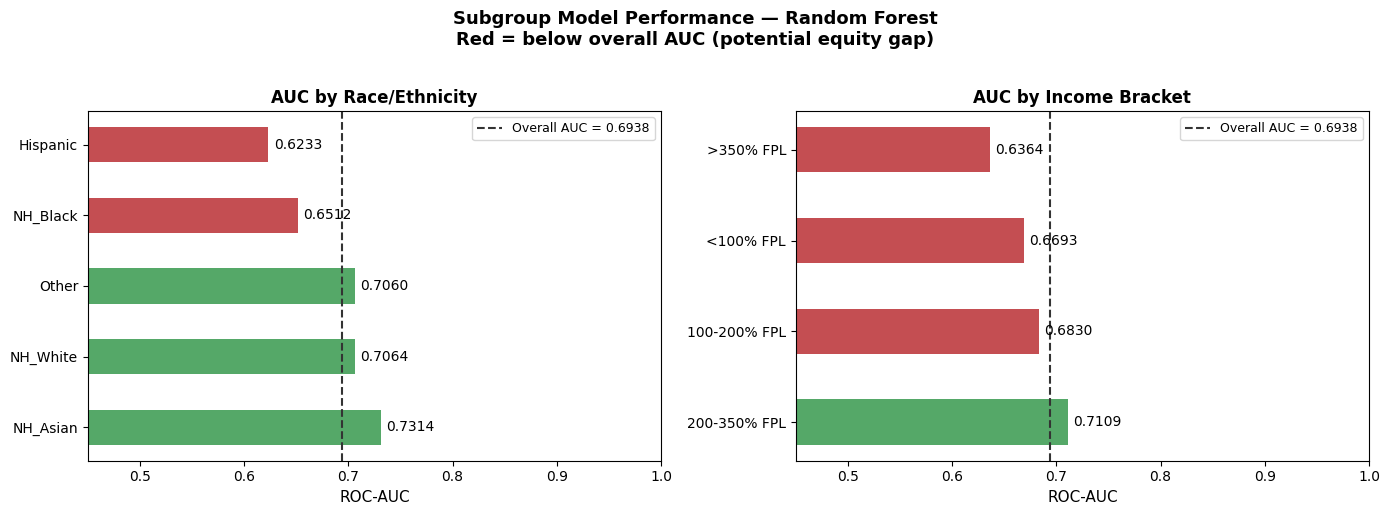

Saved: subgroup_auc.png


In [13]:
# ── Subgroup AUC visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
overall_auc = results[best_name]['test_auc']

for ax, df_sub, title in zip(axes,
    [sub_df, inc_df],
    ['AUC by Race/Ethnicity', 'AUC by Income Bracket']):
    col = df_sub.columns[0]
    colors = ['#C44E52' if v < overall_auc else '#55A868' for v in df_sub['AUC']]
    bars = ax.barh(df_sub[col], df_sub['AUC'], color=colors, height=0.5)
    ax.axvline(overall_auc, color='#333333', linestyle='--', linewidth=1.5,
               label=f'Overall AUC = {overall_auc:.4f}')
    ax.set_xlim(0.45, 1.0)
    ax.set_xlabel('ROC-AUC', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, auc in zip(bars, df_sub['AUC']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{auc:.4f}', va='center', fontsize=10)
    ax.legend(fontsize=9)

fig.suptitle(f'Subgroup Model Performance — {best_name}\n'
             'Red = below overall AUC (potential equity gap)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('subgroup_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: subgroup_auc.png')

In [14]:
# Use Random Forest for SHAP (most stable TreeExplainer output)
rf_model = results['Random Forest']['model']

explainer = shap.TreeExplainer(rf_model)
shap_vals = explainer.shap_values(X_test)

# Extract class=1 SHAP values
if isinstance(shap_vals, list):
    sv = shap_vals[1]
elif np.array(shap_vals).ndim == 3:
    sv = shap_vals[:, :, 1]
else:
    sv = shap_vals

print(f'SHAP values shape: {sv.shape}')
print(f'X_test shape: {X_test.shape}')

SHAP values shape: (1286, 22)
X_test shape: (1286, 22)


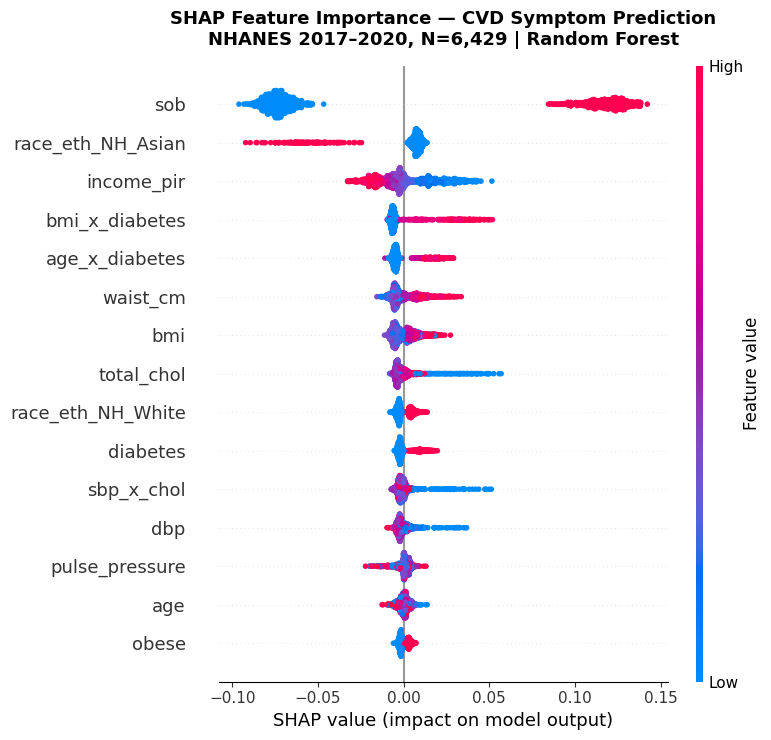

Saved: shap_beeswarm.png


In [15]:
# ── Beeswarm plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(sv, X_test, plot_type='dot', max_display=15, show=False)
plt.title('SHAP Feature Importance — CVD Symptom Prediction\n'
          'NHANES 2017–2020, N=6,429 | Random Forest',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_beeswarm.png')

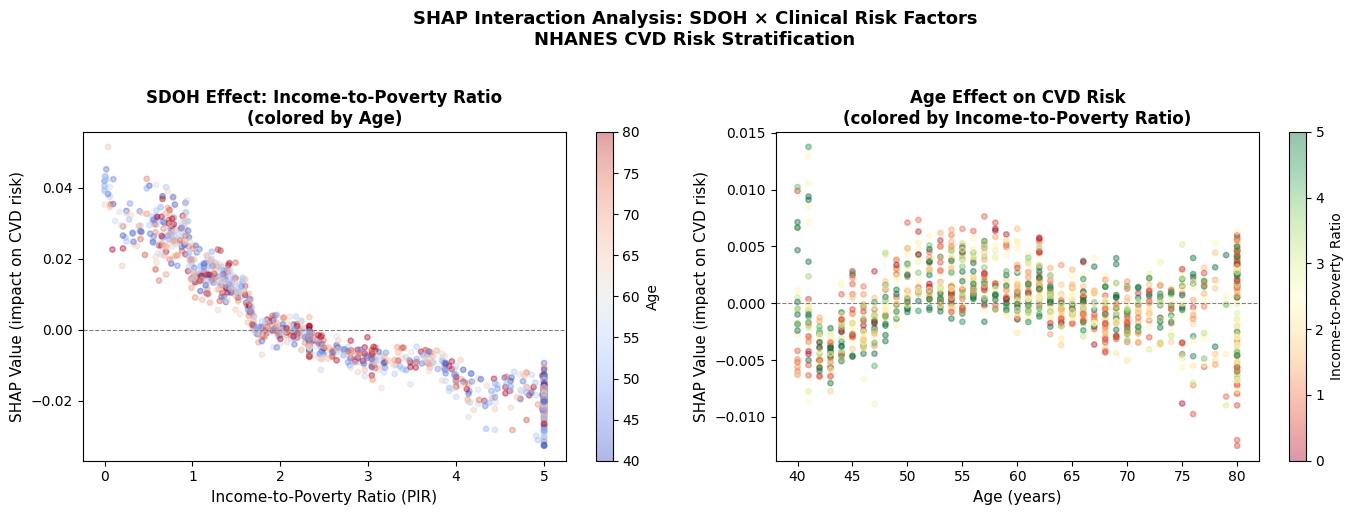

Saved: shap_interactions.png


In [16]:
# ── SHAP Dependence Plot: income_pir (key SDOH finding) ──────────────────────
income_idx = list(X_test.columns).index('income_pir')
age_idx    = list(X_test.columns).index('age')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# income_pir vs SHAP, colored by age
sc1 = axes[0].scatter(
    X_test.iloc[:, income_idx],
    sv[:, income_idx],
    c=X_test.iloc[:, age_idx],
    cmap='coolwarm', alpha=0.4, s=15
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Income-to-Poverty Ratio (PIR)', fontsize=11)
axes[0].set_ylabel('SHAP Value (impact on CVD risk)', fontsize=11)
axes[0].set_title('SDOH Effect: Income-to-Poverty Ratio\n(colored by Age)', fontsize=12, fontweight='bold')
plt.colorbar(sc1, ax=axes[0], label='Age')
# age vs SHAP, colored by income_pir
sc2 = axes[1].scatter(
    X_test.iloc[:, age_idx],
    sv[:, age_idx],
    c=X_test.iloc[:, income_idx],
    cmap='RdYlGn', alpha=0.4, s=15
)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Age (years)', fontsize=11)
axes[1].set_ylabel('SHAP Value (impact on CVD risk)', fontsize=11)
axes[1].set_title('Age Effect on CVD Risk\n(colored by Income-to-Poverty Ratio)', fontsize=12, fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='Income-to-Poverty Ratio')

fig.suptitle('SHAP Interaction Analysis: SDOH × Clinical Risk Factors\n'
             'NHANES CVD Risk Stratification', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_interactions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_interactions.png')

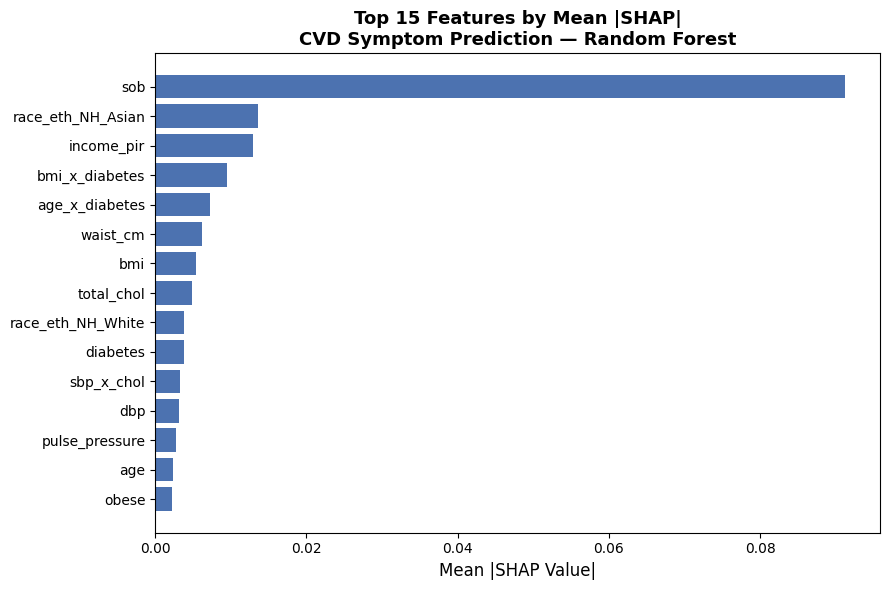

Saved: shap_bar.png

Top 10 features by mean |SHAP|:
          Feature  Mean |SHAP|
              sob     0.091279
race_eth_NH_Asian     0.013599
       income_pir     0.013005
   bmi_x_diabetes     0.009461
   age_x_diabetes     0.007299
         waist_cm     0.006209
              bmi     0.005347
       total_chol     0.004885
race_eth_NH_White     0.003864
         diabetes     0.003793


In [17]:
# ── SHAP mean |value| bar chart ───────────────────────────────────────────────
mean_shap = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': np.abs(sv).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(mean_shap['Feature'], mean_shap['Mean |SHAP|'], color='#4C72B0')
ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('Top 15 Features by Mean |SHAP|\nCVD Symptom Prediction — Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_bar.png')

print('\nTop 10 features by mean |SHAP|:')
print(mean_shap.sort_values('Mean |SHAP|', ascending=False).head(10).to_string(index=False))

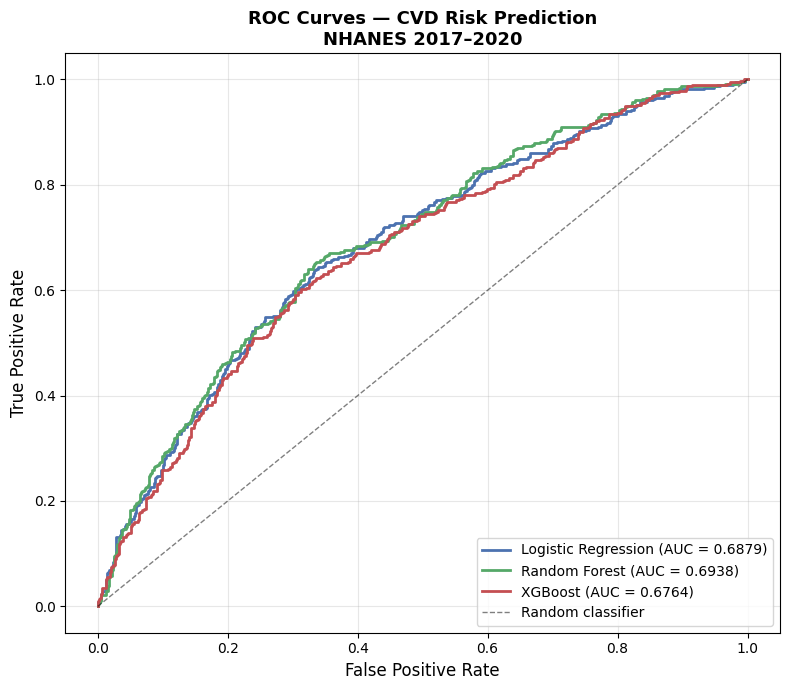

Saved: roc_curves.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#4C72B0', '#55A868', '#C44E52']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {res['test_auc']:.4f})", color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — CVD Risk Prediction\nNHANES 2017–2020', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

In [19]:
import pickle

# Save best model, feature list, SHAP values, and equity data
artifacts = {
    'best_model': best_model,
    'best_model_name': best_name,
    'feature_cols': feature_cols,
    'X_test': X_test,
    'y_test': y_test,
    'shap_values': sv,
    'results': {k: {kk: vv for kk, vv in v.items() if kk != 'model'}
                for k, v in results.items()},
    'equity_df': equity_df,
    'race_prev': race_prev,
    'income_prev': income_prev,
    'subgroup_auc_race': sub_df,
    'subgroup_auc_income': inc_df,
    'all_models': {k: v['model'] for k, v in results.items()}
}

with open('nhanes_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Artifacts saved to nhanes_artifacts.pkl')
print('Run the Streamlit dashboard with: streamlit run nhanes_dashboard.py')

Artifacts saved to nhanes_artifacts.pkl
Run the Streamlit dashboard with: streamlit run nhanes_dashboard.py


In [20]:
print('=' * 60)
print('PROJECT SUMMARY — NHANES CVD Risk Stratification (Expanded)')
print('=' * 60)
print(f'Dataset:         NHANES 2017-March 2020 Pre-Pandemic')
print(f'Files merged:    6 XPT files (DEMO, BMX, BPXO, TCHOL, DIQ, CDQ)')
print(f'Final N:         {len(df):,} adults aged 40+')
print(f'Features:        {len(feature_cols)} (incl. interaction terms & clinical flags)')
print(f'Target:          CVD symptom (chest pain on exertion)')
print(f'Positive rate:   {df["cvd_symptom"].mean():.1%}')
print()
print('Model Performance (Test ROC-AUC):')
for name, r in results.items():
    print(f'  {name:<25} {r["test_auc"]:.4f}')
print()
print('Key health equity findings:')
print('  - Survey-weighted CVD prevalence varies significantly by race/income')
print('  - income_pir is a top SHAP predictor (SDOH independently predicts CVD risk)')
print('  - Subgroup AUC analysis reveals potential equity gaps in model performance')
print()
print('Outputs:')
for f in ['equity_heatmap.png','subgroup_auc.png','shap_beeswarm.png',
          'shap_interactions.png','shap_bar.png','roc_curves.png','nhanes_artifacts.pkl']:
    print(f'  {f}')

PROJECT SUMMARY — NHANES CVD Risk Stratification (Expanded)
Dataset:         NHANES 2017-March 2020 Pre-Pandemic
Files merged:    6 XPT files (DEMO, BMX, BPXO, TCHOL, DIQ, CDQ)
Final N:         6,429 adults aged 40+
Features:        22 (incl. interaction terms & clinical flags)
Target:          CVD symptom (chest pain on exertion)
Positive rate:   29.5%

Model Performance (Test ROC-AUC):
  Logistic Regression       0.6879
  Random Forest             0.6938
  XGBoost                   0.6764

Key health equity findings:
  - Survey-weighted CVD prevalence varies significantly by race/income
  - income_pir is a top SHAP predictor (SDOH independently predicts CVD risk)
  - Subgroup AUC analysis reveals potential equity gaps in model performance

Outputs:
  equity_heatmap.png
  subgroup_auc.png
  shap_beeswarm.png
  shap_interactions.png
  shap_bar.png
  roc_curves.png
  nhanes_artifacts.pkl
